In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent

## Roadmap

1. Load an edm4hep file
2. Load the particles and tracker hits


## Loading

In [2]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [4]:
ST_file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root"
ST_event = EDM4hepEvent(ST_file_path, event_index=0, detector_params=detector_params)
ST_particles = ST_event.get_particles_df()
ST_hits = ST_event.get_tracker_hits_df()
ST_calo_hits = ST_event.get_calo_contributions_df()

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root...
  Loaded 15 particles.
  Loaded 14 tracker hits.
  Loaded 95 calo hits and 250 contributions.


In [24]:
# Use uproot to read the file
import uproot

# Read the file
file = uproot.open("/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root")

# Get the tree
tree = file["events"]

# Get the branches
branches = tree.arrays()

In [28]:
# Use uproot to read the file
import uproot

# Read the file
file = uproot.open("/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v4/runs/all/edm4hep.root")

# Get the tree
tree = file["events"]

# Get the branches
branches = tree.arrays()

In [25]:
tree

<TTree 'events' (41 branches) at 0x7f664e22ee90>

In [26]:
branches

<Array [{...}, {...}, {...}, ..., {...}, {...}] type='20 * {"ECalBarrelColl...'>

In [29]:
branches

<Array [{...}, {...}, {...}, ..., {...}, {...}] type='10 * {"ECalBarrelColl...'>

In [27]:
branches[0], branches[9], branches[10]

(<Record {...} type='{"ECalBarrelCollection.cellID": var * uint64, "ECalBarr...'>,
 <Record {...} type='{"ECalBarrelCollection.cellID": var * uint64, "ECalBarr...'>,
 <Record {...} type='{"ECalBarrelCollection.cellID": var * uint64, "ECalBarr...'>)

In [5]:
ST_file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root"
ST_event = EDM4hepEvent(ST_file_path, event_index=1, detector_params=detector_params)
ST_particles = ST_event.get_particles_df()
ST_hits = ST_event.get_tracker_hits_df()
ST_calo_hits = ST_event.get_calo_contributions_df()

Loading event 1 from /pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root...
  Loaded 15 particles.
  Loaded 14 tracker hits.
  Loaded 95 calo hits and 250 contributions.


## Plotting

In [6]:
ST_tracker_reco_particles = ST_particles[ST_particles.index.isin(ST_hits.particle_id)]

In [7]:
ST_tracker_reco_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,13,1,33554432,-1.0,8.022988,0.105658,0.003668,0.003056,140.592569,2.560188,...,0.228517,0.004774,2768.897426,10.000558,9.8949,194,False,True,False,False


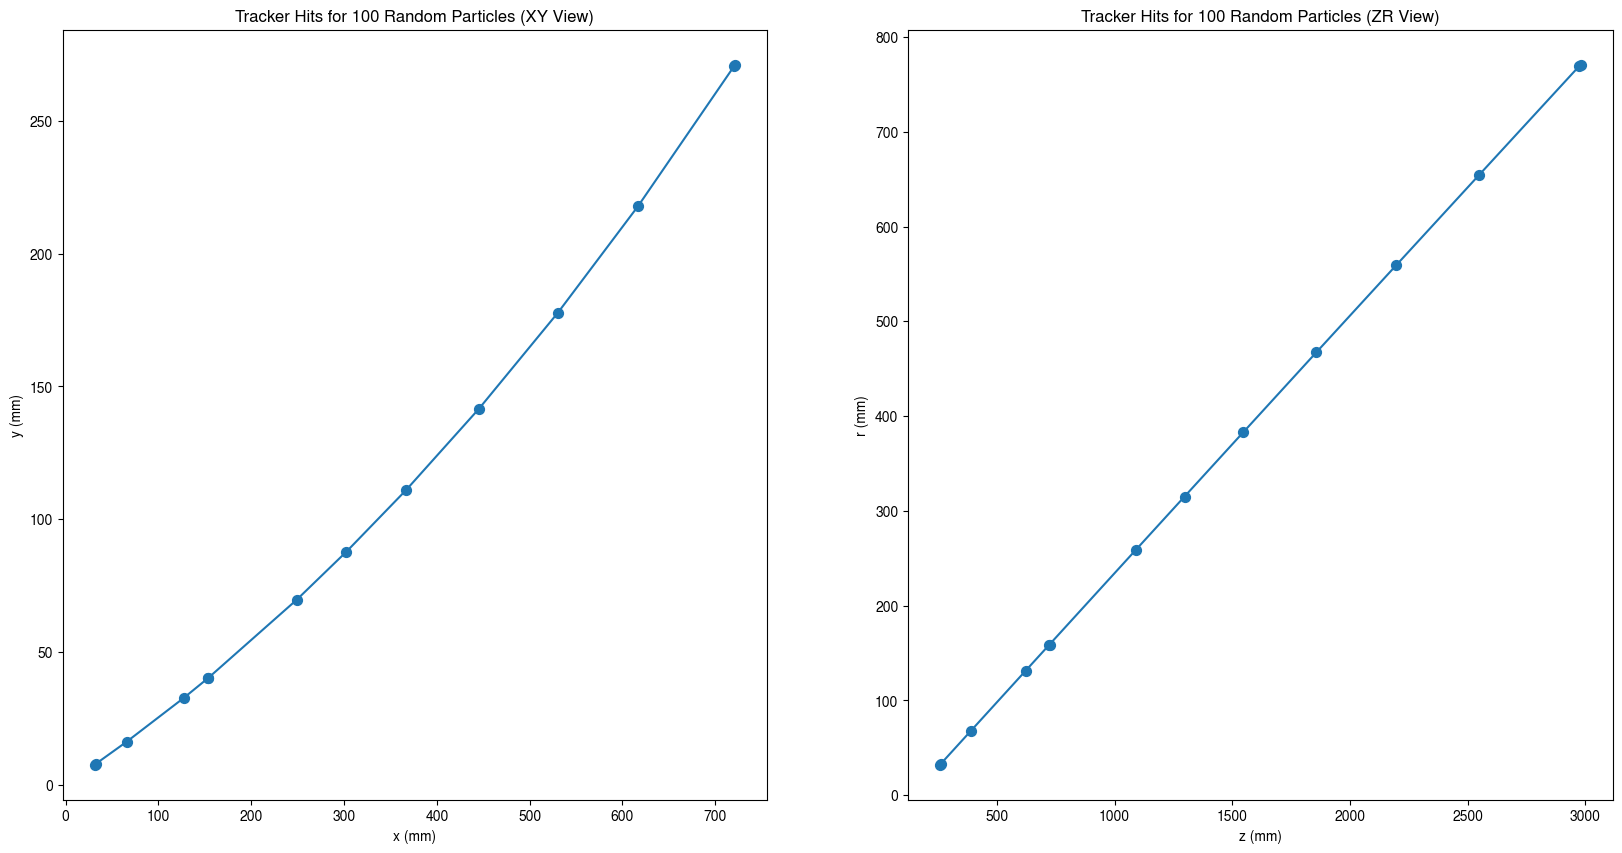

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the hits, colored by particle id
for particle_id in ST_tracker_reco_particles.index:
    particle_hits = ST_hits[ST_hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()

## Loading

In [9]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [30]:
MT_file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v4/runs/all/edm4hep.root"
MT_event = EDM4hepEvent(MT_file_path, event_index=0, detector_params=detector_params)
MT_particles = MT_event.get_particles_df()
MT_hits = MT_event.get_tracker_hits_df()
MT_calo_hits = MT_event.get_calo_contributions_df()

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v4/runs/all/edm4hep.root...
  Loaded 7 particles.
  Loaded 15 tracker hits.
  Loaded 95 calo hits and 190 contributions.


In [33]:
MT_file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v4/runs/all/edm4hep.root"
MT_event = EDM4hepEvent(MT_file_path, event_index=9999, detector_params=detector_params)
MT_particles = MT_event.get_particles_df()
MT_hits = MT_event.get_tracker_hits_df()
MT_calo_hits = MT_event.get_calo_contributions_df()

Loading event 9999 from /pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v4/runs/all/edm4hep.root...
  Loaded 16 particles.
  Loaded 23 tracker hits.
  Loaded 99 calo hits and 261 contributions.


## Plotting

In [34]:
MT_tracker_reco_particles = MT_particles[MT_particles.index.isin(MT_hits.particle_id)]

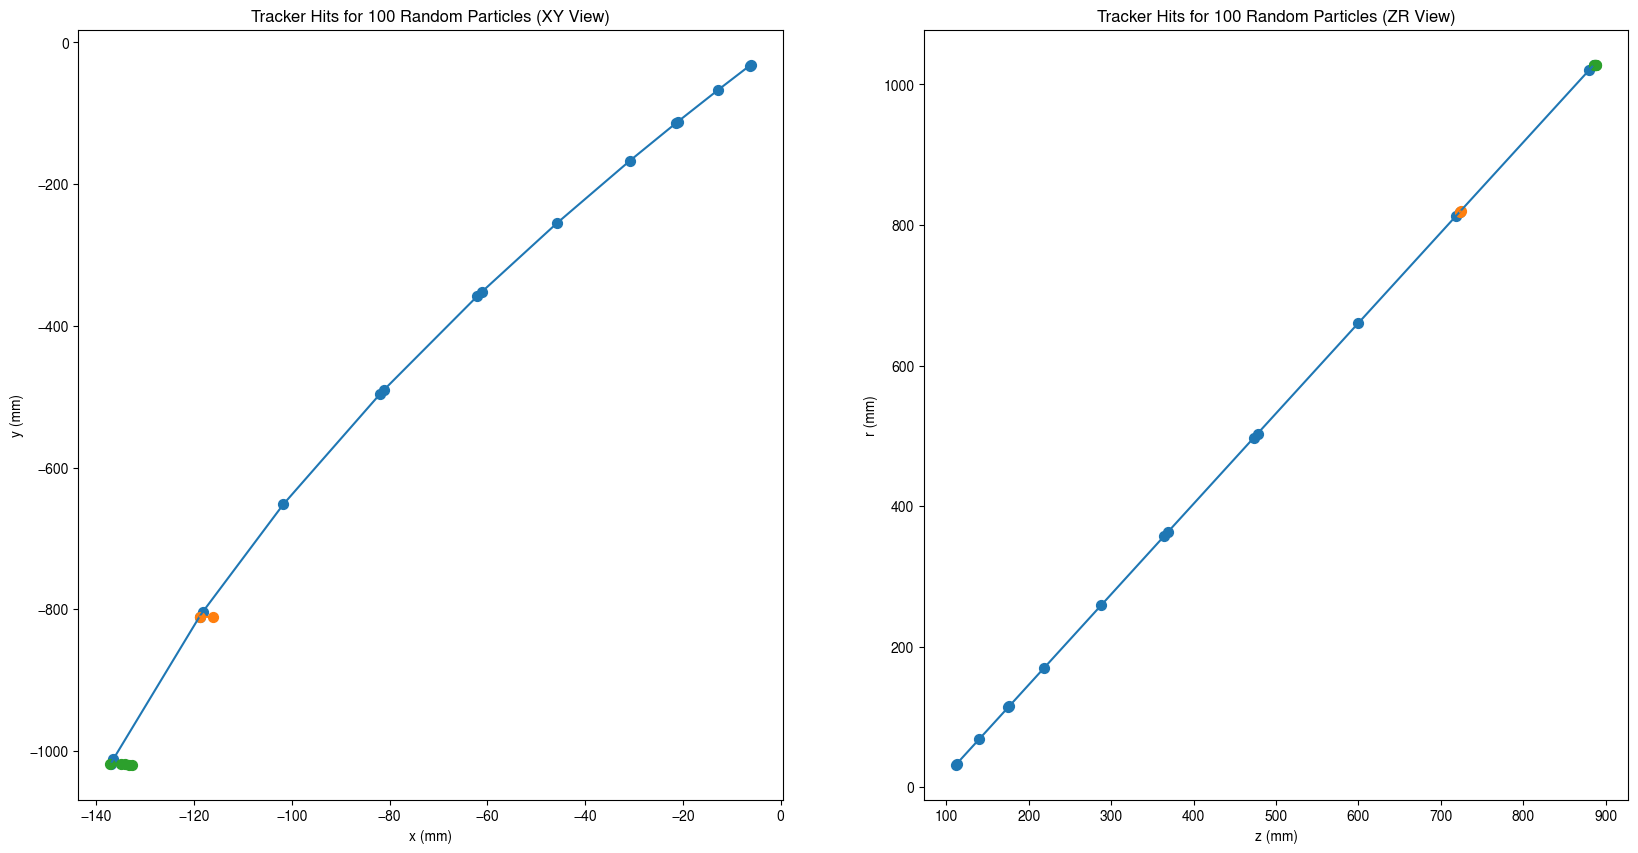

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the hits, colored by particle id
for particle_id in MT_tracker_reco_particles.index:
    particle_hits = MT_hits[MT_hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()